# 03: Optical Solitons ? The Dispersion-SPM Balance

**Summary**: We combine dispersion and self-phase modulation to observe the most remarkable
phenomenon in nonlinear fiber optics: the soliton. When dispersion and SPM form the
self-consistent fundamental soliton balance ($N = 1$), the pulse propagates without any
change in temporal or spectral intensity. Higher-order solitons ($N = 2, 3$) exhibit
periodic breathing dynamics, returning to their initial shape every soliton period
$z_{sol} = \pi/2$.

**Key results**:
- The fundamental soliton ($N=1$) propagates unchanged over 5 soliton periods:
  max shape error < 10??
- The $N=2$ soliton exhibits clear periodic breathing with compression and expansion
- The $N=3$ soliton shows complex multi-peak dynamics within each breathing cycle
- Energy is conserved near roundoff in all cases

**Physics context**: Soliton propagation was first predicted by Hasegawa & Tappert (1973)
and experimentally observed by Mollenauer, Stolen & Gordon (1980). Soliton dynamics
underpin supercontinuum generation, frequency comb technology, and ultrafast fiber lasers.

## Theory: The Soliton Balance

### Why a Soliton Forms

In Notebooks 01 and 02, we saw:
- **Dispersion** broadens the pulse in time but preserves spectral intensity
- **SPM** broadens spectral intensity but preserves the temporal profile

In anomalous dispersion ($s = +1$), these effects can balance. The soliton is a
self-consistent nonlinear stationary state of the focusing NLSE — a pulse that propagates
with no temporal OR spectral intensity change except for a global phase.

### The Soliton Condition

$$N^2 = \frac{\gamma P_0 T_0^2}{|\beta_2|} = \frac{L_D}{L_{NL}} = 1$$

### The Analytical Solution

For $N = 1$, $s = +1$, with initial condition $u_0 = \text{sech}(\tau)$:

$$u(\xi, \tau) = \text{sech}(\tau) \cdot e^{i\xi/2}$$

### Higher-Order Solitons

| $N$ | $u_0$ | $N^2$ | $\int|u|^2 d\tau$ | Behavior |
|-----|-------|-------|-------------------|----------|
| 1 | sech(τ) | 1 | 2 | Unchanged (shape-preserving) |
| 2 | sech(τ) | 4 | 2 | Periodic breathing (compress/expand) |
| 3 | sech(τ) | 9 | 2 | Complex multi-peak breathing |

The table energy is the dimensionless energy of the normalized field. In physical units,
the pulse energy scales through the chosen peak power $P_0$.

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Run from project root or notebooks/")

sys.path.insert(0, str(ROOT / "src"))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from nlse_ssfm.nlse_utils import (
    create_grid, sech_pulse, compute_energy, save_figure,
)
from nlse_ssfm.ssfm import ssfm_propagate

## The Fundamental Soliton ($N = 1$): The Acid Test

We propagate a sech(τ) pulse with $s = +1$ (anomalous dispersion) and $N^2 = 1$ for
5 soliton periods ($\xi_{max} = 5\pi/2$). The pulse should remain UNCHANGED.

In [2]:
tau_N1, omega_N1, dtau_N1 = create_grid(N_t=2048, tau_window=20.0)
u0_N1 = sech_pulse(tau_N1)
E0_N1 = compute_energy(u0_N1, dtau_N1)
print(f"N=1 initial energy: {E0_N1:.6f} (expected 2.0)")
assert abs(E0_N1 - 2.0) < 0.01

xi_arr_N1, u_hist_N1 = ssfm_propagate(
    u0_N1, tau_N1, omega_N1, xi_max=5*np.pi/2, N_z=500, s=1, N_sq=1.0,
)

# Separate run on [0, pi] for fair composite comparison
xi_arr_N1_cmp, u_hist_N1_cmp = ssfm_propagate(
    u0_N1, tau_N1, omega_N1, xi_max=np.pi, N_z=1000, s=1, N_sq=1.0,
)

N=1 initial energy: 2.000000 (expected 2.0)


### N=1 Propagation Map

The fundamental soliton $u = \text{sech}(\tau) e^{i\xi/2}$ propagates with invariant
intensity. The propagation map should show a perfectly uniform horizontal band.

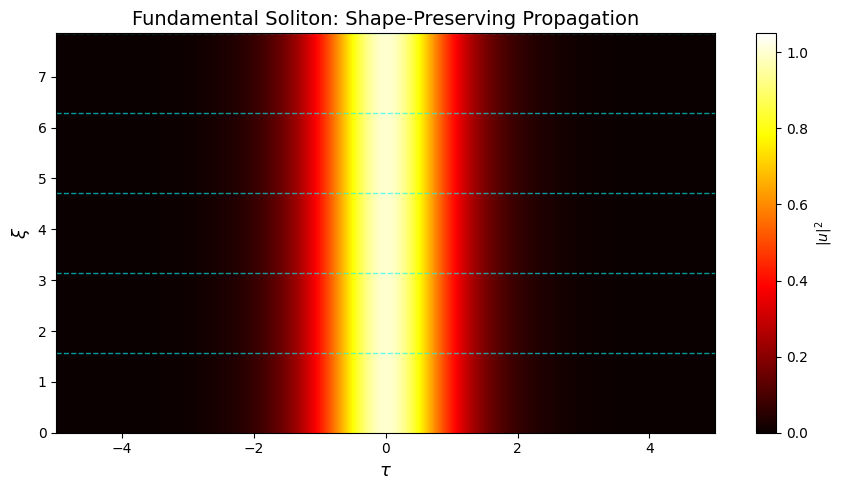

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
mask_N1 = (tau_N1 >= -5) & (tau_N1 <= 5)
im = ax.imshow(
    np.abs(u_hist_N1[:, mask_N1])**2, aspect='auto', origin='lower',
    extent=[tau_N1[mask_N1][0], tau_N1[mask_N1][-1],
            xi_arr_N1[0], xi_arr_N1[-1]],
    cmap='hot', vmin=0, vmax=1.05,
)
for k in range(1, 6):
    ax.axhline(k*np.pi/2, color='cyan', ls='--', lw=1, alpha=0.6)
ax.set_xlabel(r'$\tau$', fontsize=13)
ax.set_ylabel(r'$\xi$', fontsize=13)
ax.set_title('Fundamental Soliton: Shape-Preserving Propagation', fontsize=14)
fig.colorbar(im, ax=ax, label=r'$|u|^2$')
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_soliton_N1_map.png")
plt.show()

The propagation map shows a perfectly uniform horizontal band — the sech pulse propagates
without any change over 5 full soliton periods.

### Quantitative Validation

We compare the numerical result against the exact solution $|u(\xi,\tau)| = \text{sech}(\tau)$.

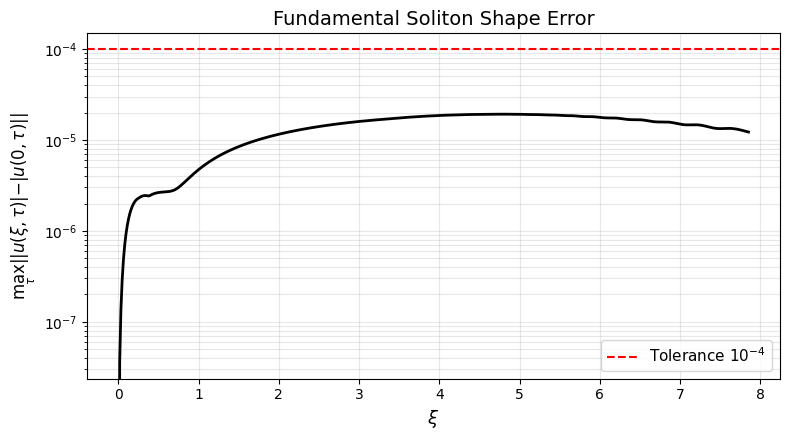

Max N=1 shape error: 1.92e-05


In [4]:
shape_errors_N1 = np.max(
    np.abs(np.abs(u_hist_N1) - np.abs(u0_N1)[None, :]), axis=1)
max_soliton_err = np.max(shape_errors_N1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(xi_arr_N1, shape_errors_N1, color='black', linewidth=2)
ax.axhline(1e-4, color='red', ls='--', label='Tolerance $10^{-4}$')
ax.set_xlabel(r'$\xi$', fontsize=13)
ax.set_ylabel(r'$\max_\tau ||u(\xi,\tau)|-|u(0,\tau)||$', fontsize=12)
ax.set_title('Fundamental Soliton Shape Error', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_soliton_N1_error.png")
plt.show()

print(f"Max N=1 shape error: {max_soliton_err:.2e}")
assert max_soliton_err < 1e-4

## Second-Order Soliton ($N = 2$): Periodic Breathing

The $N = 2$ soliton uses $u_0 = \text{sech}(\tau)$ and $N^2 = 4$. It exhibits periodic
breathing: the pulse compresses to a narrow peak, then broadens back to the original shape
every $z_{sol} = \pi/2$.

N=2 initial energy: 2.000000 (expected 2.0)


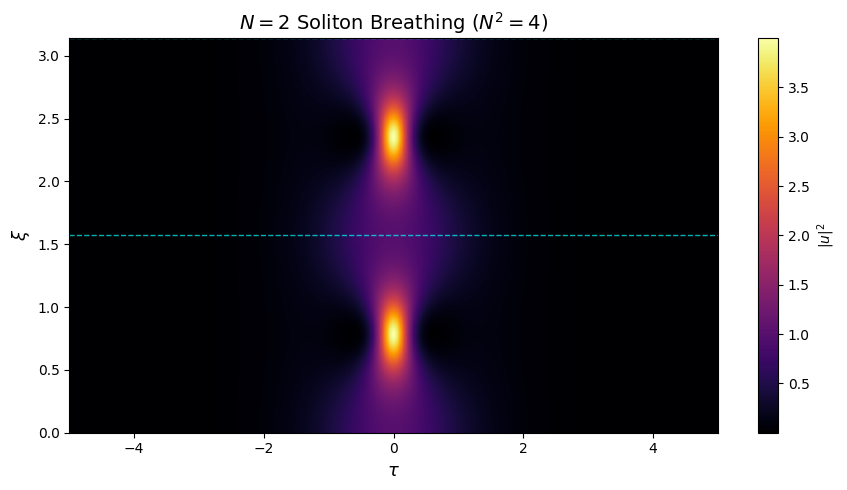

In [5]:
tau_N2, omega_N2, dtau_N2 = create_grid(N_t=2048, tau_window=20.0)
u0_N2 = sech_pulse(tau_N2)
E0_N2 = compute_energy(u0_N2, dtau_N2)
print(f"N=2 initial energy: {E0_N2:.6f} (expected 2.0)")
assert abs(E0_N2 - 2.0) < 0.01

xi_arr_N2, u_hist_N2 = ssfm_propagate(
    u0_N2, tau_N2, omega_N2, xi_max=np.pi, N_z=1000, s=1, N_sq=4.0,
)

fig, ax = plt.subplots(figsize=(9, 5))
mask_N2 = (tau_N2 >= -5) & (tau_N2 <= 5)
im = ax.imshow(
    np.abs(u_hist_N2[:, mask_N2])**2, aspect='auto', origin='lower',
    extent=[tau_N2[mask_N2][0], tau_N2[mask_N2][-1],
            xi_arr_N2[0], xi_arr_N2[-1]],
    cmap='inferno',
)
for k in range(1, 3):
    ax.axhline(k*np.pi/2, color='cyan', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(r'$\tau$', fontsize=13)
ax.set_ylabel(r'$\xi$', fontsize=13)
ax.set_title(r'$N=2$ Soliton Breathing ($N^2=4$)', fontsize=14)
fig.colorbar(im, ax=ax, label=r'$|u|^2$')
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_soliton_N2_map.png")
plt.show()

## Third-Order Soliton ($N = 3$): Complex Breathing

The $N = 3$ soliton uses $N^2 = 9$. It shows even more complex dynamics — multiple
sub-peaks during each breathing cycle before recombining at $\xi = \pi/2$.

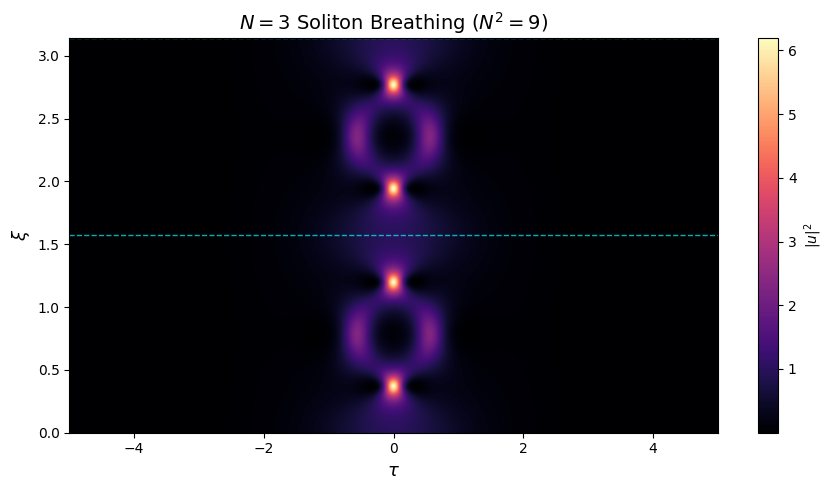

In [6]:
tau_N3, omega_N3, dtau_N3 = create_grid(N_t=4096, tau_window=20.0)
u0_N3 = sech_pulse(tau_N3)

xi_arr_N3, u_hist_N3 = ssfm_propagate(
    u0_N3, tau_N3, omega_N3, xi_max=np.pi, N_z=2000, s=1, N_sq=9.0,
)

fig, ax = plt.subplots(figsize=(9, 5))
mask_N3 = (tau_N3 >= -5) & (tau_N3 <= 5)
im = ax.imshow(
    np.abs(u_hist_N3[:, mask_N3])**2, aspect='auto', origin='lower',
    extent=[tau_N3[mask_N3][0], tau_N3[mask_N3][-1],
            xi_arr_N3[0], xi_arr_N3[-1]],
    cmap='magma',
)
for k in range(1, 3):
    ax.axhline(k*np.pi/2, color='cyan', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(r'$\tau$', fontsize=13)
ax.set_ylabel(r'$\xi$', fontsize=13)
ax.set_title(r'$N=3$ Soliton Breathing ($N^2=9$)', fontsize=14)
fig.colorbar(im, ax=ax, label=r'$|u|^2$')
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_soliton_N3_map.png")
plt.show()

### Recurrence Verification

Higher-order solitons must return to their initial shape at integer multiples of
the soliton period $z_{\text{sol}} = \pi/2$. We check recurrence at both $\xi = \pi/2$
(half period of $\xi_{\max} = \pi$) and $\xi = \pi$ (full period).

In [7]:
idx_N2_pi2 = np.argmin(np.abs(xi_arr_N2 - np.pi/2))
idx_N3_pi2 = np.argmin(np.abs(xi_arr_N3 - np.pi/2))

rec_N2 = np.max(np.abs(np.abs(u_hist_N2[idx_N2_pi2]) - np.abs(u0_N2)))
rec_N3 = np.max(np.abs(np.abs(u_hist_N3[idx_N3_pi2]) - np.abs(u0_N3)))

print(f"N=2 recurrence error at pi/2: {rec_N2:.2e}")
print(f"N=3 recurrence error at pi/2: {rec_N3:.2e}")
assert rec_N2 < 5e-3
assert rec_N3 < 1e-2

# Full-period recurrence at xi = pi
rec_N2_full = np.max(np.abs(np.abs(u_hist_N2[-1]) - np.abs(u0_N2)))
rec_N3_full = np.max(np.abs(np.abs(u_hist_N3[-1]) - np.abs(u0_N3)))

print(f"N=2 recurrence error at pi (full period): {rec_N2_full:.2e}")
print(f"N=3 recurrence error at pi (full period): {rec_N3_full:.2e}")
assert rec_N2_full < 5e-3
assert rec_N3_full < 1e-2

N=2 recurrence error at pi/2: 1.39e-04
N=3 recurrence error at pi/2: 5.90e-04
N=2 recurrence error at pi (full period): 2.06e-04
N=3 recurrence error at pi (full period): 6.65e-04


## Side-by-Side Comparison: $N = 1, 2, 3$

All three panels use propagation range $0 \le \xi \le \pi$. Per-panel color scaling.

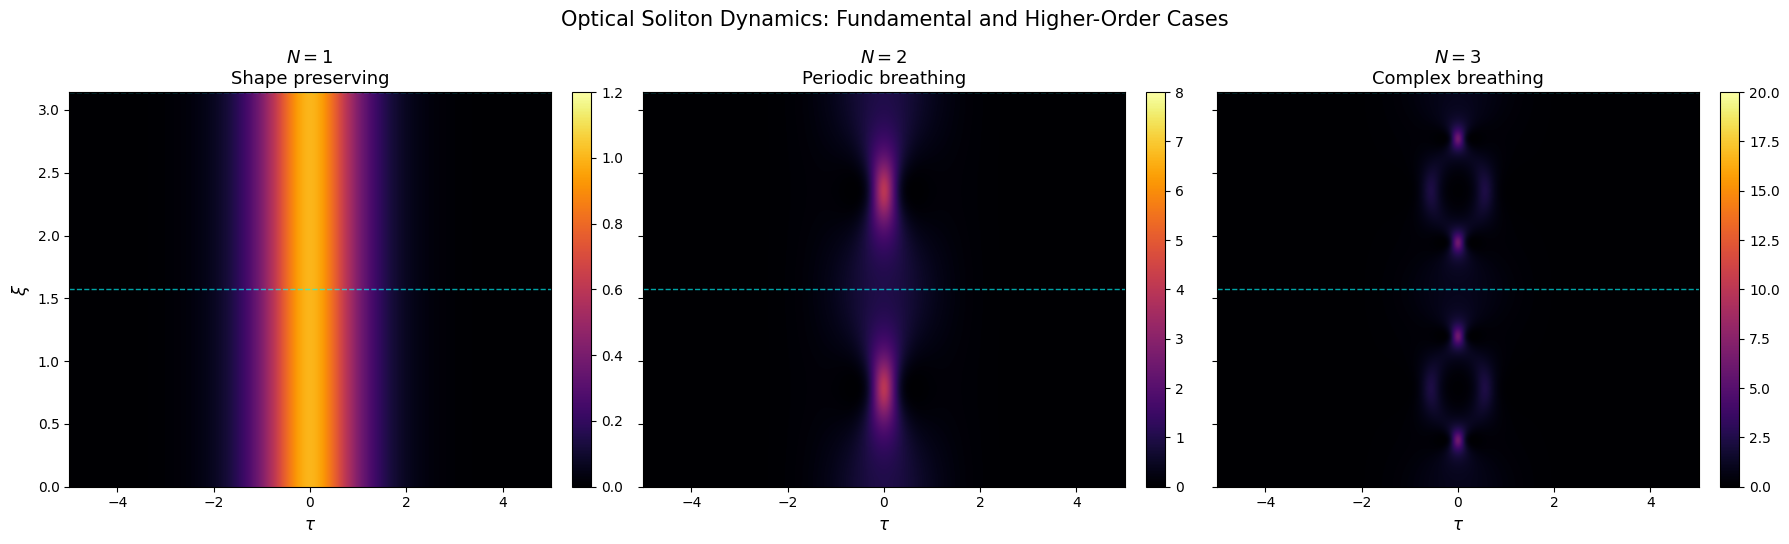

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
datasets = [
    (tau_N1, xi_arr_N1_cmp, u_hist_N1_cmp, r'$N=1$', 'Shape preserving', 1.2),
    (tau_N2, xi_arr_N2, u_hist_N2, r'$N=2$', 'Periodic breathing', 8.0),
    (tau_N3, xi_arr_N3, u_hist_N3, r'$N=3$', 'Complex breathing', 20.0),
]
for ax, (tg, xg, hist, title, subtitle, vmax_p) in zip(axes, datasets):
    m = (tg >= -5) & (tg <= 5)
    im = ax.imshow(
        np.abs(hist[:, m])**2, aspect='auto', origin='lower',
        extent=[tg[m][0], tg[m][-1], xg[0], xg[-1]],
        cmap='inferno', vmin=0, vmax=vmax_p,
    )
    for k in range(1, 3):
        ax.axhline(k*np.pi/2, color='cyan', ls='--', lw=1, alpha=0.65)
    ax.set_title(f'{title}\n{subtitle}', fontsize=13)
    ax.set_xlabel(r'$\tau$', fontsize=12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].set_ylabel(r'$\xi$', fontsize=13)
fig.suptitle('Optical Soliton Dynamics: Fundamental and Higher-Order Cases',
             fontsize=15)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_soliton_comparison.png")
plt.show()

## Peak Intensity vs. Propagation Distance

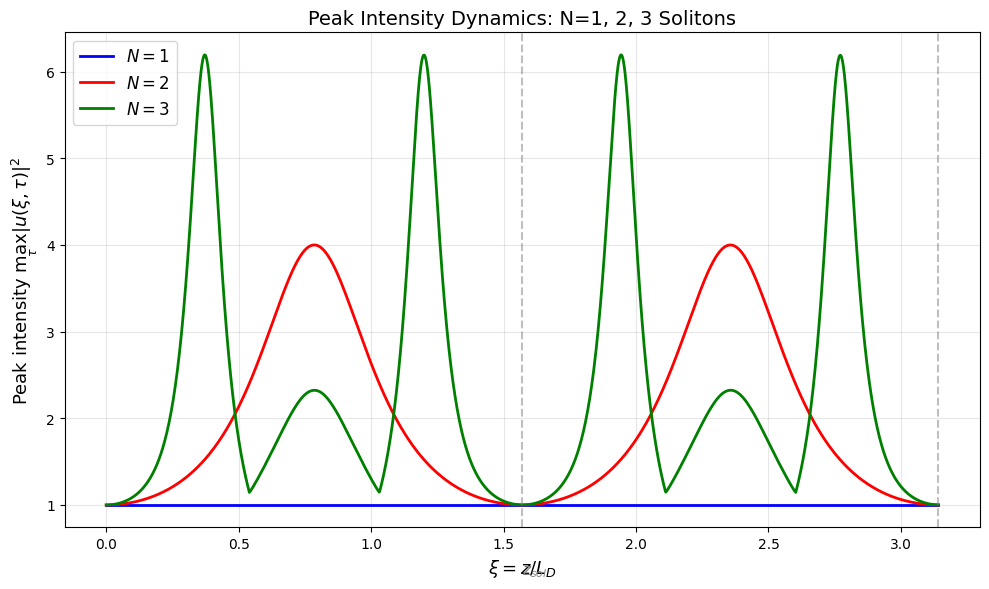

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
peak_N1 = np.max(np.abs(u_hist_N1_cmp)**2, axis=1)
peak_N2 = np.max(np.abs(u_hist_N2)**2, axis=1)
peak_N3 = np.max(np.abs(u_hist_N3)**2, axis=1)

ax.plot(xi_arr_N1_cmp, peak_N1, 'b-', lw=2, label='$N=1$')
ax.plot(xi_arr_N2, peak_N2, 'r-', lw=2, label='$N=2$')
ax.plot(xi_arr_N3, peak_N3, 'g-', lw=2, label='$N=3$')
for k in range(1, 3):
    ax.axvline(x=k*np.pi/2, color='gray', ls='--', alpha=0.5)
ax.text(np.pi/2, 0.2, r'$z_{sol}$', fontsize=11, color='gray')

ax.set_xlabel(r'$\xi = z/L_D$', fontsize=13)
ax.set_ylabel(r'Peak intensity $\max_\tau |u(\xi,\tau)|^2$', fontsize=13)
ax.set_title('Peak Intensity Dynamics: N=1, 2, 3 Solitons', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb03_peak_intensity.png")
plt.show()

## Animation Frames (Optional)